In [65]:
import warnings,re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
 
warnings.filterwarnings("ignore")




In [66]:
ASSET_COLORS = {
    'Sub Centre':                '#42a5f5',
    'Primary Health Centre':     '#66bb6a',
    'Community Health Centre':   '#ffa726',
    'Sub District Hospital':     '#ef5350',
    'CHC - With Maternity Ward': '#ab47bc',
    'District Hospital':         '#26c6da',
    'Other  - Health facility':  '#8d6e63',
}
ASSET_SHORT = {
    'Sub Centre':                'Sub Ctr',
    'Primary Health Centre':     'PHC',
    'Community Health Centre':   'CHC',
    'Sub District Hospital':     'SDH',
    'CHC - With Maternity Ward': 'CHC+MW',
    'District Hospital':         'Dist. Hosp',
    'Other  - Health facility':  'Other',
}



In [67]:
root = "/Users/saurabhlevin/Deployment/flood-data-ecosystem-Himachal-Pradesh/Sources/HPSDMA/PDNA/PDNA-2025/"

In [68]:
PWD_CSV  = root + "pwd.csv"
CA_CSV   = root + "community_assets_flat.csv"
H_CSV    = root + "health.csv"
OUT_XLSX = root + "district_block_infra_damage.xlsx"
OUT_PNG  = root + "infra_damage_dashboard.png"

DIST_MAP ={"LAHAUL AND SPITI": "LAHAUL & SPITI",
    "LAHAUL SPITI":     "LAHAUL & SPITI",
    "SIRMOUR":          "SIRMAUR",
}

def norm(s):
    s= str(s).upper().strip()
    return DIST_MAP.get(s, s)




In [69]:
####PWD###
pwd = pd.read_csv(PWD_CSV, low_memory=False)
pwd = pwd[pwd["District"].notna()].copy()
pwd["District"] = pwd["District"].apply(norm)
pwd["Section"]  = pwd["Section"].fillna("Unknown").str.strip()

PWD_LEN_COLS = {
    "Road_TotalCollapse_m":   "Length of Totally Damaged Roads (in meters)",
    "Road_Severe_m":          "Length of Severely Damaged Roads (in meters)",
    "Road_Minor_m":           "Length of Minor Damaged Roads (in Meters)",
    "RetainingWall_m":        "Length of Retaining Wall Damaged (in meters)",
    "BreastWall_m":           "Length of Breast Wall Damaged (in meters)",
    "Drainage_m":             "Length of Roadside Drainage Damaged (in meters)",
}

COUNT_COLS = {
    
    'HumePipes_n':  'Number of Hume Pipes Damaged',
    'Culverts_n':   'Number of Slab / Box Culvert Damage',
    'Causeways_n':  'Number of Causeway  Damaged',
}

for alias, col in {**PWD_LEN_COLS,**COUNT_COLS}.items():
    pwd[alias]= pd.to_numeric(pwd[col], errors ="coerce").fillna(0)
    
pwd['Road_Total_All_m'] = (
    pwd['Road_TotalCollapse_m'] +
    pwd['Road_Severe_m'] +
    pwd['Road_Minor_m']
)

pwd["Incidents"]          = 1

agg_cols = list(PWD_LEN_COLS.keys()) + list(COUNT_COLS.keys())+ ["Road_Total_All_m", "Incidents"]

#DISTRCIT AGGREGATION 

pwd_dist =pwd.groupby("District")[agg_cols].sum().reset_index()
pwd_dist = pwd_dist.sort_values("Road_Total_All_m", ascending=False)

#bllock proxy aggregation
pwd_sec = pwd.groupby(["District","Section"])[agg_cols].sum().reset_index()
pwd_sec  = pwd_sec.sort_values(["District", "Road_Total_All_m"], ascending=[True, False])

print(f"  Records: {len(pwd):,}  |  Districts: {pwd['District'].nunique()}")
print(f"  Total road length damaged (all severity): {pwd['Road_Total_All_m'].sum()/1000:,.1f} km")
print(f"\n  Top 5 districts by total road damage:")
for _, r in pwd_dist.head(5).iterrows():
    print(f"    {r['District']:<18}  Road={r['Road_Total_All_m']/1000:>7.1f}km  "
          f"Wall={r['RetainingWall_m']/1000:>6.1f}km  "
          f"Drain={r['Drainage_m']/1000:>6.1f}km  "
          f"Incidents={int(r['Incidents'])}")
 
agg_pwd = agg_cols


  Records: 12,958  |  Districts: 12
  Total road length damaged (all severity): 3,470.0 km

  Top 5 districts by total road damage:
    KANGRA              Road=  897.3km  Wall=  31.7km  Drain= 128.3km  Incidents=2756
    MANDI               Road=  627.4km  Wall=  80.8km  Drain= 296.3km  Incidents=2289
    BILASPUR            Road=  492.0km  Wall=  20.8km  Drain= 145.7km  Incidents=1137
    SHIMLA              Road=  434.6km  Wall=  51.2km  Drain= 154.5km  Incidents=1164
    HAMIRPUR            Road=  344.9km  Wall=  19.6km  Drain= 144.5km  Incidents=1092


In [70]:
display(pwd_dist[['District',
                  'Road_Total_All_m',
                  'Road_TotalCollapse_m',
                  'Road_Severe_m',
                  'Road_Minor_m',
                  'RetainingWall_m',
                  'Drainage_m',
                  'Incidents']]
        .assign(**{c: pwd_dist[c]/1000
                   for c in ['Road_Total_All_m','Road_TotalCollapse_m',
                              'Road_Severe_m','Road_Minor_m',
                              'RetainingWall_m','Drainage_m']})
        .rename(columns={
            'Road_Total_All_m':    'Total Road (km)',
            'Road_TotalCollapse_m':'Collapse (km)',
            'Road_Severe_m':       'Severe (km)',
            'Road_Minor_m':        'Minor (km)',
            'RetainingWall_m':     'Ret.Wall (km)',
            'Drainage_m':          'Drainage (km)',
        }))
 

,District,Total Road (km),Collapse (km),Severe (km),Minor (km),Ret.Wall (km),Drainage (km),Incidents
3,KANGRA,897.276695,123.2310,373.838195,400.2075,31.6955,128.33000,2756
7,MANDI,627.368480,175.1125,255.307980,196.9480,80.8448,296.28100,2289
0,BILASPUR,492.001000,176.9350,158.929000,156.1370,20.8050,145.66700,1137
8,SHIMLA,434.592500,163.0660,164.877500,106.6490,51.1760,154.54500,1164
2,HAMIRPUR,344.861200,150.6930,77.757700,116.4105,19.5933,144.53300,1092
9,SIRMAUR,183.760750,64.2910,57.736750,61.7330,10.5090,34.37238,713
11,UNA,132.850000,42.4100,25.466000,64.9740,7.5660,12.22900,390
5,KULLU,99.083000,43.4190,36.842000,18.8220,17.2415,37.47100,1222
6,LAHAUL & SPITI,97.246000,40.8610,41.430000,14.9550,1.9140,2.67337,182
1,CHAMBA,89.078000,37.2060,31.505000,20.3670,29.1975,24.58300,1090


In [71]:
pwd_sec['Road_Total_All_km'] = pwd_sec['Road_Total_All_m'] / 1000
 
print('Top 15 Sections by total road damage:')
display(pwd_sec.nlargest(15, 'Road_Total_All_km')
        [['District','Section','Road_Total_All_km','RetainingWall_m','Drainage_m','Incidents']]
        .rename(columns={'Road_Total_All_km':'Road (km)',
                         'RetainingWall_m':  'Ret.Wall (m)',
                         'Drainage_m':       'Drainage (m)'})
        .reset_index(drop=True))
 

Top 15 Sections by total road damage:


,District,Section,Road (km),Ret.Wall (m),Drainage (m),Incidents
0,KANGRA,Boh(Darini sub division),161.1900,487.0,0.0,91
1,BILASPUR,Nakhlehra(Jhandutta),101.1200,3970.0,32670.0,62
2,BILASPUR,Geherwin(Jhandutta),89.6400,3037.0,35490.0,71
3,BILASPUR,Jhandutta(Jhandutta),81.5500,2760.0,20210.0,49
4,MANDI,Kotli/satahan /bhargaon section(Kotli),73.6460,25057.0,10184.0,301
5,KANGRA,Darini(Darini sub division),65.1350,212.0,720.0,58
6,HAMIRPUR,Doh(Samirpur),61.9542,4644.0,46911.0,129
7,UNA,At bangana(Bangana),54.4000,120.0,350.0,12
8,BILASPUR,Bharari-i(Bharari),54.2680,60.0,18192.0,88
9,HAMIRPUR,Dhaneta-ii(Dhaneta),41.9350,1000.0,140.0,72


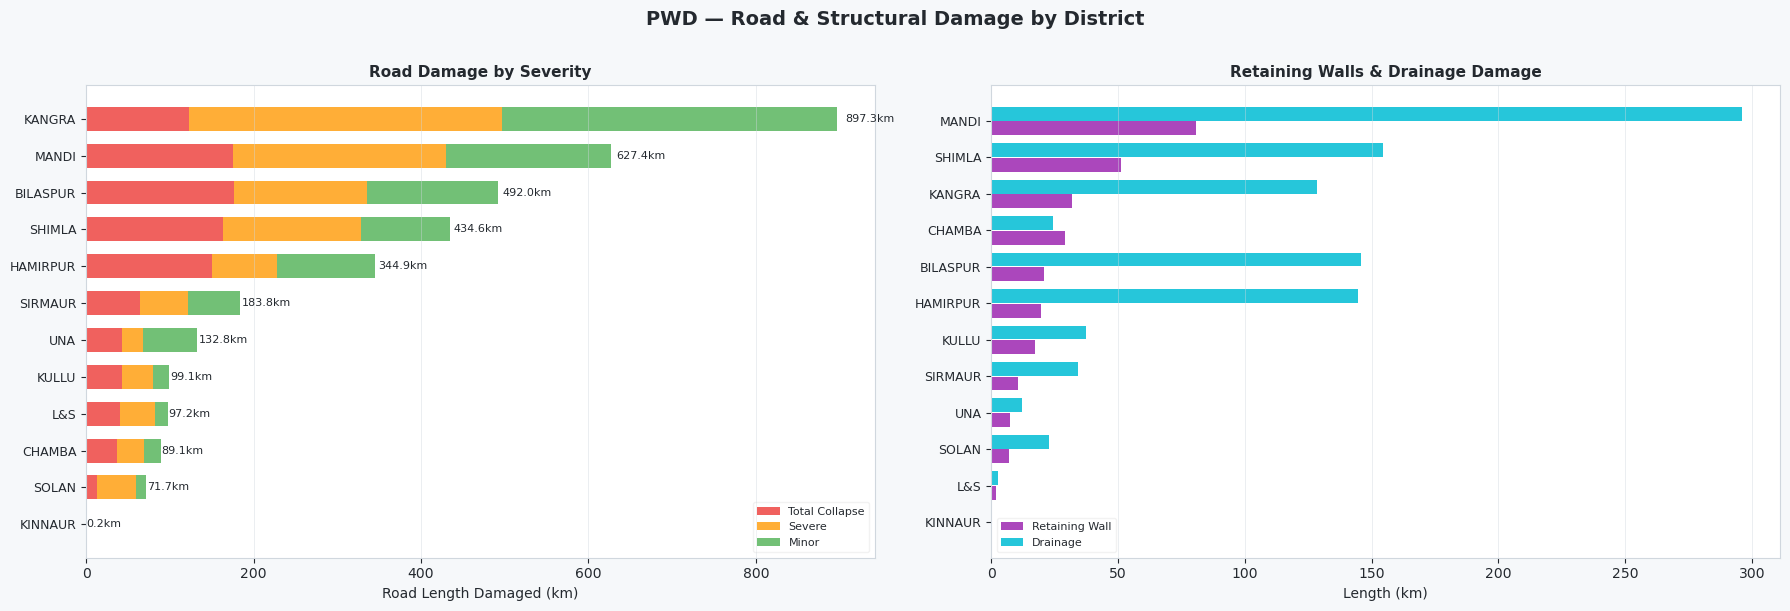

In [72]:
 
# ═══════════════════════════════════════════════════════════════
 #PWD Visualisation
# ═══════════════════════════════════════════════════════════════
 
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=LIGHT)
fig.suptitle('PWD — Road & Structural Damage by District',
             color=TEXT, fontsize=14, fontweight='bold', y=1.01)
 
# ── Left: stacked bar — road damage by severity ───────────────
ax = axes[0]
ax.set_facecolor(PANEL)
df     = pwd_dist.sort_values('Road_Total_All_m', ascending=True)
y      = np.arange(len(df))
lefts  = np.zeros(len(df))
 
for col, lbl, clr in [
        ('Road_TotalCollapse_m', 'Total Collapse', '#ef5350'),  # ← fixed
        ('Road_Severe_m',        'Severe',          '#ffa726'),
        ('Road_Minor_m',          'Minor',           '#66bb6a')]:
    v = df[col].values / 1000
    ax.barh(y, v, left=lefts, color=clr, label=lbl,
            edgecolor='none', height=0.65, alpha=0.92)
    lefts += v
 
for i, (_, r) in enumerate(df.iterrows()):
    ax.text(r['Road_Total_All_m'] / 1000 * 1.01, y[i],          # ← fixed
            f"{r['Road_Total_All_m']/1000:.1f}km",
            va='center', fontsize=8, color=TEXT)
 
ax.set_yticks(y)
ax.set_yticklabels(
    [d.replace('LAHAUL & SPITI','L&S') for d in df['District']],
    color=TEXT, fontsize=9)
ax.set_xlabel('Road Length Damaged (km)', color=TEXT, fontsize=10)
ax.set_title('Road Damage by Severity', color=TEXT, fontsize=11, fontweight='bold')
ax.tick_params(colors=TEXT)
for sp in ax.spines.values(): sp.set_color(GRID)
ax.grid(axis='x', color=GRID, lw=0.5, alpha=0.6)
ax.legend(loc='lower right', fontsize=8, framealpha=0.25, labelcolor=TEXT, facecolor=PANEL)
 
# ── Right: retaining wall vs drainage ────────────────────────
ax2 = axes[1]
ax2.set_facecolor(PANEL)
df2 = pwd_dist.sort_values('RetainingWall_m', ascending=True)
y2  = np.arange(len(df2))
 
ax2.barh(y2-0.2, df2['RetainingWall_m'].values / 1000, height=0.38,
         color='#ab47bc', edgecolor='none', label='Retaining Wall')
ax2.barh(y2+0.2, df2['Drainage_m'].values / 1000, height=0.38,    # ← fixed: was DrainageDamaged_m
         color='#26c6da', edgecolor='none', label='Drainage')
 
ax2.set_yticks(y2)
ax2.set_yticklabels(
    [d.replace('LAHAUL & SPITI','L&S') for d in df2['District']],
    color=TEXT, fontsize=9)
ax2.set_xlabel('Length (km)', color=TEXT, fontsize=10)
ax2.set_title('Retaining Walls & Drainage Damage', color=TEXT, fontsize=11, fontweight='bold')
ax2.tick_params(colors=TEXT)
for sp in ax2.spines.values(): sp.set_color(GRID)
ax2.grid(axis='x', color=GRID, lw=0.5, alpha=0.6)
ax2.legend(fontsize=8, framealpha=0.25, labelcolor=TEXT, facecolor=PANEL)
 
plt.tight_layout()
plt.savefig('pwd_district.png', dpi=150, bbox_inches='tight', facecolor=LIGHT)
plt.show()

In [77]:
ca.columns

Index(['SrNo', 'UserRole', 'UserLocLevel', 'LocationID', 'District', 'Block',
       'GP_Field', 'DisasterType', 'DisasterDate', 'GramPanchayat', 'Village',
       'VillageRoad_Km', 'VillageRoad_LossLakh', 'DebrisRemoval_Desc',
       'DebrisRemoval_CostLakh', 'WaterSupplyLine_Mts',
       'WaterSupplyLine_LossLakh', 'WaterTanks_Count', 'WaterTanks_CapLitres',
       'WaterTanks_LossLakh', 'StreetLights_Count', 'StreetLights_LossLakh',
       'PanchayatBldgs_Count', 'PanchayatBldgs_Details',
       'PanchayatBldgs_LossLakh', 'Latitude', 'Longitude', 'InfoSource',
       'PersonName', 'PhoneNo', 'TotalLoss_Lakh'],
      dtype='object')

In [82]:
#community assets 
ca_raw = pd.read_csv(CA_CSV, low_memory=False)
ca = ca_raw.iloc[1:].copy().reset_index(drop=True)
ca.columns = [
    "SrNo","UserRole","UserLocLevel","LocationID","District","Block",
    "GP_Field","DisasterType","DisasterDate","GramPanchayat","Village",
    "VillageRoad_Km","VillageRoad_LossLakh",
    "DebrisRemoval_Desc","DebrisRemoval_CostLakh",
    "WaterSupplyLine_Mts","WaterSupplyLine_LossLakh",
    "WaterTanks_Count","WaterTanks_CapLitres","WaterTanks_LossLakh",
    "StreetLights_Count","StreetLights_LossLakh",
    "PanchayatBldgs_Count","PanchayatBldgs_Details","PanchayatBldgs_LossLakh",
    "Latitude","Longitude","InfoSource","PersonName","PhoneNo","TotalLoss_Lakh",
]
ca = ca[ca["District"].notna()].copy()
ca["District"] = ca["District"].apply(norm)
ca["Block"]    = ca["Block"].fillna("Unknown").str.strip().str.title()
 
# Fix VillageRoad_Km: values > 100 are clearly in meters → convert to km
ca["VillageRoad_Km_raw"] = pd.to_numeric(ca["VillageRoad_Km"], errors="coerce").fillna(0)
ca["VillageRoad_Km_fix"] = ca["VillageRoad_Km_raw"].apply(
    lambda x: x / 1000 if x > 100 else x
)
 
# Other numeric cols
CA_METRIC_COLS = {
    "VillageRoad_Km":         "VillageRoad_Km_fix",
    "VillageRoad_LossLakh":   "VillageRoad_LossLakh",
    "DebrisRemoval_CostLakh": "DebrisRemoval_CostLakh",
    "WaterSupplyLine_Mts":    "WaterSupplyLine_Mts",
    "WaterSupplyLine_LossLakh":"WaterSupplyLine_LossLakh",
    "WaterTanks_Count":       "WaterTanks_Count",
    "WaterTanks_LossLakh":    "WaterTanks_LossLakh",
    "StreetLights_Count":     "StreetLights_Count",
    "StreetLights_LossLakh":  "StreetLights_LossLakh",
    "PanchayatBldgs_Count":   "PanchayatBldgs_Count",
    "PanchayatBldgs_LossLakh":"PanchayatBldgs_LossLakh",
    "TotalLoss_Lakh":"TotalLoss_Lakh"

}

for alias, col in CA_METRIC_COLS.items():
    ca[alias] = pd.to_numeric(ca[col], errors="coerce").fillna(0)
 
ca["Incidents"] = 1
ca_agg_cols = list(CA_METRIC_COLS.keys()) + ["Incidents"]
 
# District aggregation
ca_dist = ca.groupby("District")[ca_agg_cols].sum().reset_index()
ca_dist = ca_dist.sort_values("VillageRoad_Km", ascending=False)
 
# Block aggregation
ca_block = ca.groupby(["District","Block"])[ca_agg_cols].sum().reset_index()
ca_block = ca_block.sort_values(["District","VillageRoad_Km"], ascending=[True,False])
 
print(f"  Records: {len(ca):,}  |  Districts: {ca['District'].nunique()}  |  Blocks: {ca['Block'].nunique()}")
print(f"  Total village road damaged: {ca['VillageRoad_Km'].sum():,.1f} km (after unit fix)")
print(f"  Total water tanks damaged: {int(ca['WaterTanks_Count'].sum())}")
print(f"  Total street lights damaged: {int(ca['StreetLights_Count'].sum())}")
print(f"  Total panchayat buildings: {int(ca['PanchayatBldgs_Count'].sum())}")
print(f"\n  Top 5 districts by village road damage:")
for _, r in ca_dist.head(5).iterrows():
    print(f"    {r['District']:<18}  Road={r['VillageRoad_Km']:>7.1f}km  "
          f"Tanks={int(r['WaterTanks_Count']):>4}  "
          f"Lights={int(r['StreetLights_Count']):>4}  "
          f"Bldgs={int(r['PanchayatBldgs_Count']):>4}  "
          f"Incidents={int(r['Incidents'])}")
agg_ca = ca_agg_cols

  Records: 5,475  |  Districts: 12  |  Blocks: 70
  Total village road damaged: 6,947.5 km (after unit fix)
  Total water tanks damaged: 314
  Total street lights damaged: 751
  Total panchayat buildings: 631

  Top 5 districts by village road damage:
    CHAMBA              Road= 2295.1km  Tanks=  95  Lights= 151  Bldgs= 250  Incidents=1368
    KANGRA              Road= 1115.9km  Tanks=  18  Lights=  18  Bldgs=  73  Incidents=901
    MANDI               Road=  960.6km  Tanks= 130  Lights= 285  Bldgs=  89  Incidents=457
    SOLAN               Road=  828.5km  Tanks=   7  Lights=  39  Bldgs=  21  Incidents=675
    KULLU               Road=  530.6km  Tanks=  27  Lights=  46  Bldgs=  60  Incidents=299


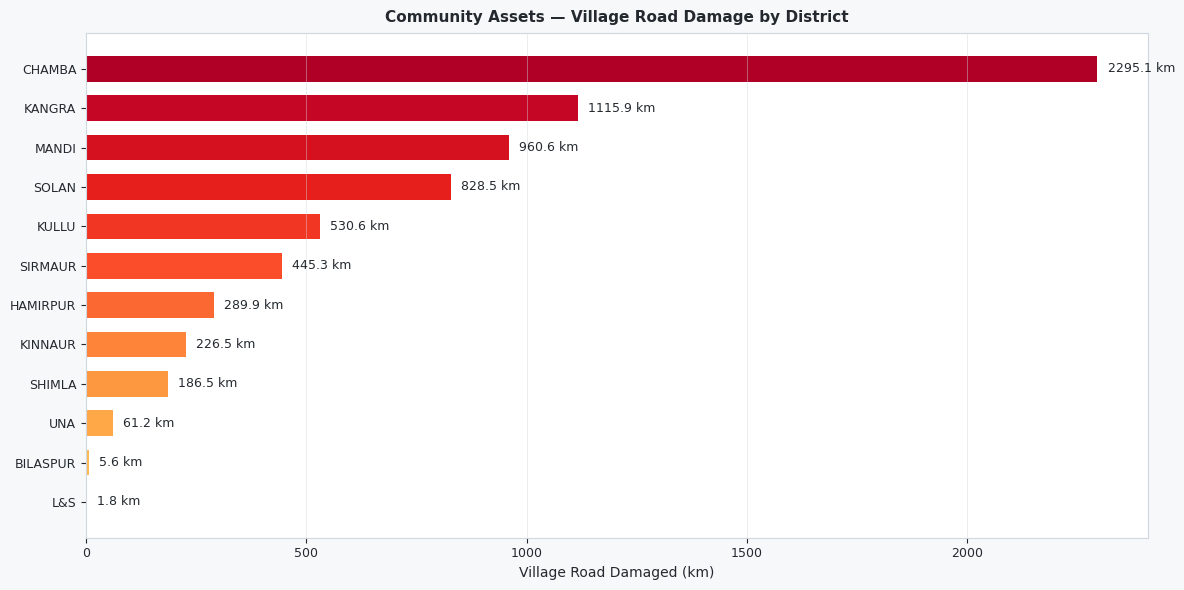

In [83]:
#Districts Analysis 
def style_ax(ax, title, xlabel=''):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, color=TEXT, fontsize=10)
    ax.tick_params(colors=TEXT, labelsize=9)
    for sp in ax.spines.values(): sp.set_color(GRID)
    ax.grid(axis='x', color=GRID, lw=0.5, alpha=0.6)
    
fig, ax = plt.subplots(figsize=(12, 6), facecolor=LIGHT)
style_ax(ax, 'Community Assets — Village Road Damage by District', 'Village Road Damaged (km)')

df = ca_dist.sort_values('VillageRoad_Km', ascending=True)
y  = np.arange(len(df))
clrs = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(df)))
bars = ax.barh(y, df['VillageRoad_Km'].values, color=clrs, edgecolor='none', height=0.65)

for b, v in zip(bars, df['VillageRoad_Km'].values):
    ax.text(v + df['VillageRoad_Km'].max()*0.01,
            b.get_y() + b.get_height()/2,
            f'{v:.1f} km', va='center', fontsize=9, color=TEXT)

ax.set_yticks(y)
ax.set_yticklabels([d.replace('LAHAUL & SPITI','L&S') for d in df['District']],
                   color=TEXT, fontsize=9)

plt.tight_layout()
plt.savefig('ca_road_district.png', dpi=150, bbox_inches='tight', facecolor=LIGHT)
plt.show()

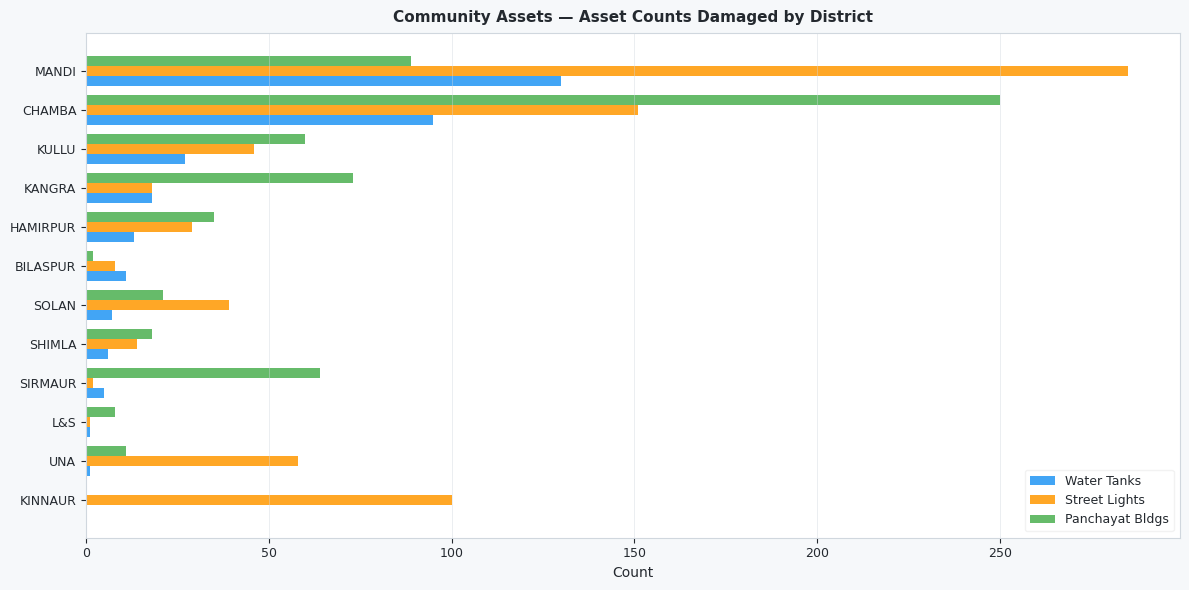

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6), facecolor=LIGHT)
style_ax(ax, 'Community Assets — Asset Counts Damaged by District', 'Count')

df = ca_dist.sort_values('WaterTanks_Count', ascending=True)
y  = np.arange(len(df))

ax.barh(y-0.26, df['WaterTanks_Count'].values,     height=0.25, color='#42a5f5',
        edgecolor='none', label='Water Tanks')
ax.barh(y+0.00, df['StreetLights_Count'].values,   height=0.25, color='#ffa726',
        edgecolor='none', label='Street Lights')
ax.barh(y+0.26, df['PanchayatBldgs_Count'].values, height=0.25, color='#66bb6a',
        edgecolor='none', label='Panchayat Bldgs')

ax.set_yticks(y)
ax.set_yticklabels([d.replace('LAHAUL & SPITI','L&S') for d in df['District']],
                   color=TEXT, fontsize=9)
ax.legend(fontsize=9, framealpha=0.25, labelcolor=TEXT, facecolor=PANEL)

plt.tight_layout()
plt.savefig('ca_counts_district.png', dpi=150, bbox_inches='tight', facecolor=LIGHT)
plt.show()

In [81]:
ca_dist.columns

Index(['District', 'VillageRoad_Km', 'VillageRoad_LossLakh',
       'DebrisRemoval_CostLakh', 'WaterSupplyLine_Mts',
       'WaterSupplyLine_LossLakh', 'WaterTanks_Count', 'WaterTanks_LossLakh',
       'StreetLights_Count', 'StreetLights_LossLakh', 'PanchayatBldgs_Count',
       'PanchayatBldgs_LossLakh', 'Incidents'],
      dtype='object')

In [ ]:
ca_dist_flat = pd.read_csv('/Users/saurabhlevin/Deployment/flood-data-ecosystem-Himachal-Pradesh/Sources/HPSDMA/PDNA/PDNA-2025/community_assets_flat.csv')
ca_dist_flat.columns

Index(['SrNo', 'UserRole', 'UserLocLevel', 'LocationID', 'District', 'Block',
       'GP_Field', 'DisasterType', 'DisasterDate', 'GramPanchayat', 'Village',
       'VillageRoad_Km', 'VillageRoad_LossLakh', 'DebrisRemoval_Desc',
       'DebrisRemoval_CostLakh', 'WaterSupplyLine_Mts',
       'WaterSupplyLine_LossLakh', 'WaterTanks_Count', 'WaterTanks_CapLitres',
       'WaterTanks_LossLakh', 'StreetLights_Count', 'StreetLights_LossLakh',
       'PanchayatBldgs_Count', 'PanchayatBldgs_Details',
       'PanchayatBldgs_LossLakh', 'Latitude', 'Longitude', 'InfoSource',
       'PersonName', 'PhoneNo', 'TotalLoss_Lakh'],
      dtype='object')

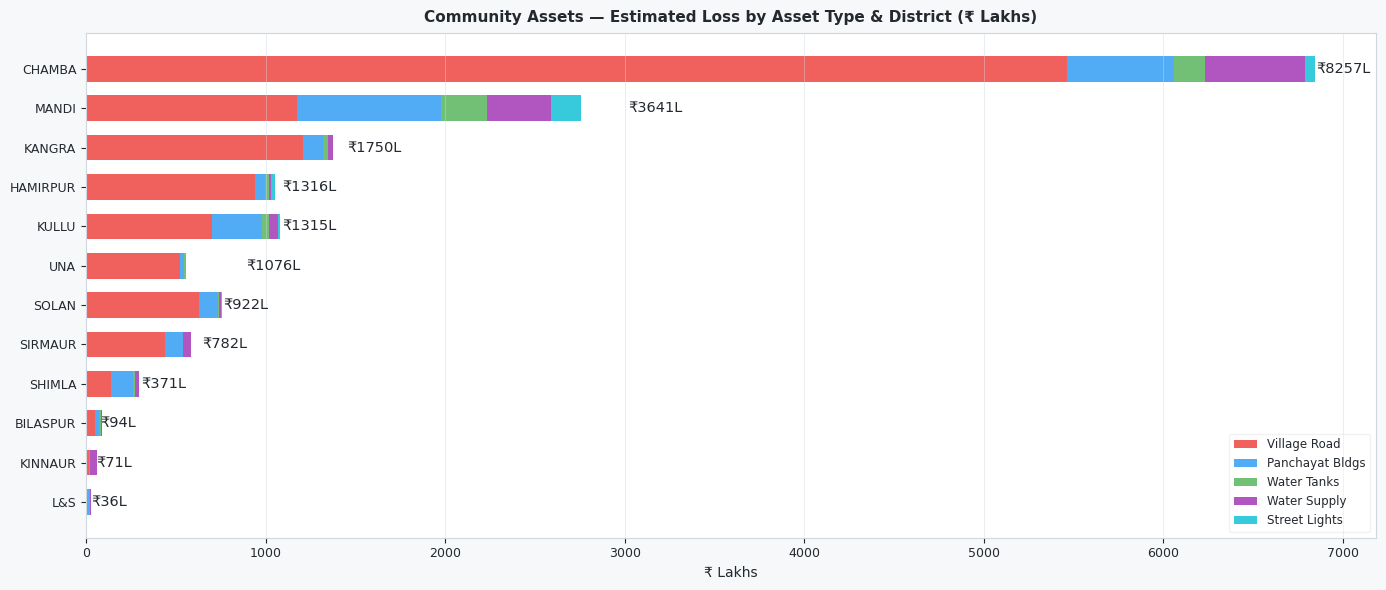

In [102]:
fig, ax = plt.subplots(figsize=(14, 6), facecolor=LIGHT)
style_ax(ax, 'Community Assets — Estimated Loss by Asset Type & District (₹ Lakhs)', '₹ Lakhs')


df = ca_dist.sort_values('TotalLoss_Lakh', ascending=True)
y  = np.arange(len(df))
lefts = np.zeros(len(df))

seg_info = [
    ('VillageRoad_LossLakh',    'Village Road',    '#ef5350'),
    ('PanchayatBldgs_LossLakh', 'Panchayat Bldgs', '#42a5f5'),
    #('DebrisRemoval_CostLakh',  'Debris Removal',  '#ffa726'),
    ('WaterTanks_LossLakh',     'Water Tanks',     '#66bb6a'),
    ('WaterSupplyLine_LossLakh','Water Supply',    '#ab47bc'),
    ('StreetLights_LossLakh',   'Street Lights',   '#26c6da'),
]
for col, lbl, clr in seg_info:
    v = df[col].values
    ax.barh(y, v, left=lefts, color=clr, label=lbl,
            edgecolor='none', height=0.65, alpha=0.92)
    lefts += v

for i, (_, r) in enumerate(df.iterrows()):
    ax.text(r['TotalLoss_Lakh']*0.83, y[i],
            f"₹{r['TotalLoss_Lakh']:.0f}L", va='center', fontsize=10.5, color=TEXT)

ax.set_yticks(y)
ax.set_yticklabels([d.replace('LAHAUL & SPITI','L&S') for d in df['District']],
                   color=TEXT, fontsize=9)
ax.legend(loc='lower right', fontsize=8.5, framealpha=0.25,
          labelcolor=TEXT, facecolor=PANEL)

plt.tight_layout()
plt.savefig('ca_loss_district.png', dpi=150, bbox_inches='tight', facecolor=LIGHT)
plt.show()

In [93]:
h = pd.read_csv(H_CSV, low_memory=False)
h = h[h['District'].notna()].copy()
h['District']  = h['District'].apply(norm)
h['AssetType'] = h['Reporting Asset_Health'].fillna('Unknown').str.strip()
h['Block']     = h['Name of Block'].fillna('Unknown').str.strip().str.title()

print(f'Records  : {len(h):,}')
print(f'Districts: {h["District"].nunique()}')
print(f'Blocks   : {h["Block"].nunique()}')
print('\nFacility types:')
display(h['AssetType'].value_counts()
        .rename_axis('Facility Type').reset_index(name='Count'))

Records  : 264
Districts: 10
Blocks   : 80

Facility types:


,Facility Type,Count
0,Sub Centre,119
1,Primary Health Centre,73
2,Community Health Centre,29
3,Sub District Hospital,19
4,Other - Health facility,14
5,CHC - With Maternity Ward,7
6,District Hospital,3


In [94]:
STRUCT_MAP = {
    'Damage Assessment on Foundation / Floor': {
        'No damage to foundation or floor':                    0,
        'There is silt on floor':                              1,
        'The building foundation has visible vertical cracks': 2,
        'floor has settled/deflected':                         3,
        'The land has subsided/shifted or settled.':           3,
    },
    'Damage Assessment Structural System': {
        'No damage on Coloums/ Structural Walls':                                                    0,
        'Visible Minor Cracks (Hairline Cracks) on Coloums/ Members':                               1,
        'Visible Deep Cracks (Prominent Cracks with more than a finger) on Coloums/ Members':       2,
        'One or more coloums/ strctural member has buckled':                                         3,
    },
    'Damage to Walls': {
        'No Damage':                                       0,
        'Minor Cracks (Hair line Crack) on wall plaster':  1,
        'Prominent Cracks on Corner of door/ window':      2,
        'Major Deep cracks on the walls':                  3,
        'Wall has collapsed':                              4,
    },
    'Damage Assessment - Roof': {
        'No Damage to the roof':                               0,
        'Small portion of the roof has damaged':               1,
        'Large portion of the roof has damaged':               2,
        'Roof/ Tin sheet has flown away':                      3,
        'RCC slab has deflected  / RCC slab has collapsed':    4,
    },
}
STRUCT_ALIAS = {
    'Damage Assessment on Foundation / Floor': 'Sev_Foundation',
    'Damage Assessment Structural System':     'Sev_Structural',
    'Damage to Walls':                         'Sev_Walls',
    'Damage Assessment - Roof':                'Sev_Roof',
}
for col, alias in STRUCT_ALIAS.items():
    h[alias] = h[col].map(STRUCT_MAP[col]).fillna(0)

struct_cols = list(STRUCT_ALIAS.values())
print('Severity columns added:', struct_cols)
h[['District','AssetType'] + struct_cols].head()

Severity columns added: ['Sev_Foundation', 'Sev_Structural', 'Sev_Walls', 'Sev_Roof']


,District,AssetType,Sev_Foundation,Sev_Structural,Sev_Walls,Sev_Roof
0,KANGRA,Sub Centre,0,0,0,1
1,UNA,Primary Health Centre,0,0,0,0
2,SOLAN,Sub Centre,2,2,3,4
3,SOLAN,Sub Centre,2,2,3,2
4,MANDI,Primary Health Centre,0,0,0,0


In [95]:
PREMISE_FLAGS = {
    'Damage to the premise/The building has washed away':                             'Prem_BldgWashedAway',
    'Damage to the premise/The land under the building is washed away':               'Prem_LandWashedAway',
    'Damage to the premise/Retaining wall in the premise is washed away':             'Prem_RetWallWashed',
    'Damage to the premise/Land is highly unstable':                                  'Prem_LandUnstable',
    'Damage to the premise/Tree has fallen on building/ premise':                     'Prem_TreeFallen',
    'Damage to the premise/High tension line has fallen on the building/ premise':    'Prem_HTPowerLine',
    'Damage to the premise/House adjacent to the building is highly unsafe':          'Prem_AdjBldgUnsafe',
    'Damage to the premise/Access road to School is damaged':                         'Prem_AccessRoadDmg',
    'Damage to the premise/Boundary Wall is damaged':                                 'Prem_BoundaryWall1',
    'Damage to the premise/Access to Anganwadi is Damaged':                           'Prem_AnganwadiAccess',
    'Damage to the premise/Access to house is damaged':                               'Prem_HouseAccess',
    'Damage to the premise/Boundary Wall is damaged.1':                               'Prem_BoundaryWall2',
    'Damage to the premise/Access to School facility is damaged':                     'Prem_SchoolAccess',
}
WATSAN_FLAGS = {
    'Damaged to Water and Sanitation/Toilet is damaged':                              'WS_ToiletDmg',
    'Damaged to Water and Sanitation/Septic tank/ Soak pit is damaged':               'WS_SepticTankDmg',
    'Damaged to Water and Sanitation/Drinking Water point is damaged/ not availble ': 'WS_DrinkingWaterDmg',
}
DISRUPTION_FLAGS = {
    'Was routine post-natal  visits disrupted because of disaster':         'Dis_PostNatal',
    'Was routine ante-natal  visits disrupted because of disaster':         'Dis_AnteNatal',
    'Cold- Chain for immunization was  breached during/ post disasters':    'Dis_ColdChain',
    'Health facility was Temporary shifted to other location':               'Dis_TempShifted',
    'Health facility is permanenetly clsoes/ shifted to other location':    'Dis_PermClosed',
}

# 0/1 flags
for orig, alias in {**PREMISE_FLAGS, **WATSAN_FLAGS}.items():
    h[alias] = pd.to_numeric(h[orig], errors='coerce').fillna(0).astype(int)

# Yes/No disruption flags → 1/0
for orig, alias in DISRUPTION_FLAGS.items():
    h[alias] = (h[orig].str.strip().str.lower() == 'yes').astype(int)

flag_cols     = list(PREMISE_FLAGS.values()) + list(WATSAN_FLAGS.values())
disrupt_cols  = list(DISRUPTION_FLAGS.values())
all_dmg_cols  = struct_cols + flag_cols

# Expenditure columns (in Rs)
EXP_COLS = {
    'Exp_DebrisCleanup_Rs':  'Additional Expenditure incurred  - Cleaning up of Debris ( IN Rupees)/ Put Zero if none',
    'Exp_TempFacility_Rs':   'Addtional Expenditure incurred - Establihing temporary health facility/ health camps (Approx amount in Rupees)',
    'Exp_Rental_Rs':         'Additional Expenditure Incurred - Cummulative rental in Rupees',
}
for alias, col in EXP_COLS.items():
    h[alias] = pd.to_numeric(h[col], errors='coerce').fillna(0)

h['TotalExp_Rs']          = h[list(EXP_COLS.keys())].sum(axis=1)
h['TotalDamageFlags']     = h[flag_cols].sum(axis=1)
h['TotalDisruptions']     = h[disrupt_cols].sum(axis=1)
h['TotalStructSeverity']  = h[struct_cols].sum(axis=1)
h['AnyStructuralDmg']     = (h[struct_cols].max(axis=1) > 0).astype(int)
h['Facilities']           = 1

print(f'Premise flags   : {len(flag_cols)}')
print(f'WatSan flags    : {len(WATSAN_FLAGS)}')
print(f'Disruption flags: {len(disrupt_cols)}')
print(f'Total damage flags across HP: {h["TotalDamageFlags"].sum()}')
print(f'Total disruptions across HP : {h["TotalDisruptions"].sum()}')
print(f'Total additional expenditure: ₹{h["TotalExp_Rs"].sum():,.0f}')

Premise flags   : 16
WatSan flags    : 3
Disruption flags: 5
Total damage flags across HP: 347
Total disruptions across HP : 99
Total additional expenditure: ₹8,143,717


In [97]:
agg_h = (all_dmg_cols + disrupt_cols +
         list(EXP_COLS.keys()) +
         ['TotalDamageFlags','TotalDisruptions','TotalStructSeverity',
          'AnyStructuralDmg','TotalExp_Rs','Facilities'])

# District level
h_dist = (h.groupby('District')[agg_h]
           .sum().reset_index()
           .sort_values('TotalDamageFlags', ascending=False))

# District × AssetType
h_asset_dist = (h.groupby(['District','AssetType'])[agg_h]
                 .sum().reset_index()
                 .sort_values(['District','TotalDamageFlags'], ascending=[True,False]))

# HP-wide by AssetType
h_asset_hp = (h.groupby('AssetType')[agg_h]
               .sum().reset_index()
               .sort_values('TotalDamageFlags', ascending=False))
h_asset_hp['AvgFlagsPerFacility'] = (h_asset_hp['TotalDamageFlags'] /
                                     h_asset_hp['Facilities']).round(2)

# Block level
h_block = (h.groupby(['District','Block'])[agg_h]
            .sum().reset_index()
            .sort_values(['District','TotalDamageFlags'], ascending=[True,False]))

# Pivot: District × AssetType → flags
pivot_flags = h.pivot_table(index='District', columns='AssetType',
                             values='TotalDamageFlags', aggfunc='sum',
                             fill_value=0).reset_index()
pivot_flags.columns.name = None
pivot_count = h.pivot_table(index='District', columns='AssetType',
                             values='Facilities', aggfunc='sum',
                             fill_value=0).reset_index()
pivot_count.columns.name = None

print('District summary:')
display(h_dist[['District','Facilities','TotalDamageFlags',
                'AnyStructuralDmg','TotalStructSeverity',
                'TotalDisruptions','TotalExp_Rs']]
        .rename(columns={'TotalDamageFlags':'DmgFlags','AnyStructuralDmg':'StructFacs',
                         'TotalStructSeverity':'StructSev','TotalDisruptions':'Disruptions',
                         'TotalExp_Rs':'Expenditure(₹)'})
        .reset_index(drop=True))

District summary:


,District,Facilities,DmgFlags,StructFacs,StructSev,Disruptions,Expenditure(₹)
0,KANGRA,74,93,60,302,27,3363512
1,SOLAN,53,72,45,223,15,457556
2,KULLU,32,57,22,98,7,1611367
3,MANDI,26,38,19,79,24,687217
4,SHIMLA,19,35,18,81,10,18000
5,CHAMBA,16,33,15,65,11,1308997
6,SIRMAUR,25,10,21,109,5,0
7,BILASPUR,5,4,5,25,0,15
8,HAMIRPUR,6,3,3,5,0,697053
9,UNA,8,2,3,6,0,0


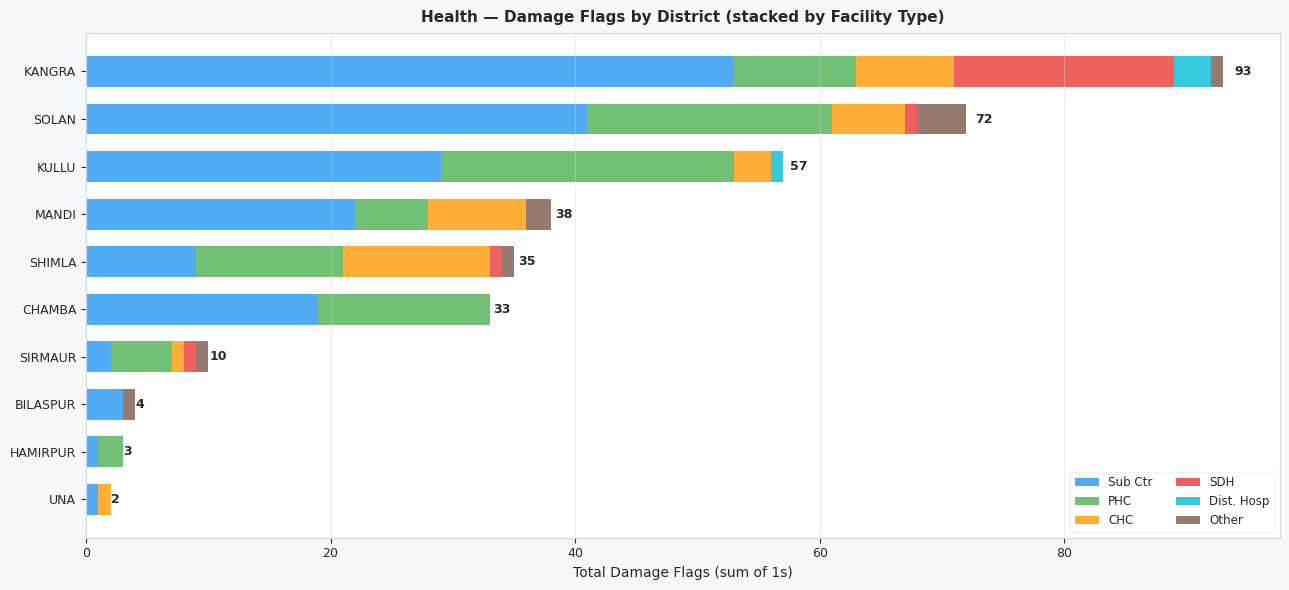

In [106]:

fig, ax = plt.subplots(figsize=(13, 6), facecolor=LIGHT)
style_ax(ax, 'Health — Damage Flags by District (stacked by Facility Type)',
         'Total Damage Flags (sum of 1s)')

PLOT_COLORS = {
    'Sub Centre':               '#42a5f5',  # deep blue
    'Primary Health Centre':    '#66bb6a',  # deep green
    'Community Health Centre':  '#ffa726',  # deep orange (combined CHC + CHC+MW)
    'Sub District Hospital':    '#ef5350',  # deep red
    'District Hospital':        '#26c6da',  # deep purple
    'Other  - Health facility': '#8d6e63',  # warm brown
}
PLOT_SHORT = {
    'Sub Centre':               'Sub Ctr',
    'Primary Health Centre':    'PHC',
    'Community Health Centre':  'CHC',
    'Sub District Hospital':    'SDH',
    'District Hospital':        'Dist. Hosp',
    'Other  - Health facility': 'Other',
}

asset_order = list(PLOT_COLORS.keys())
pf = pivot_flags.set_index('District').copy()

# Combine CHC - With Maternity Ward into Community Health Centre
if 'CHC - With Maternity Ward' in pf.columns:
    pf['Community Health Centre'] = pf.get('Community Health Centre', 0) + pf['CHC - With Maternity Ward']
    pf = pf.drop(columns=['CHC - With Maternity Ward'])

for a in asset_order:
    if a not in pf.columns: pf[a] = 0
pf['_total'] = pf[asset_order].sum(axis=1)
pf = pf.sort_values('_total', ascending=True)

y     = np.arange(len(pf))
lefts = np.zeros(len(pf))
for asset in asset_order:
    vals = pf[asset].values.astype(float)
    ax.barh(y, vals, left=lefts,
            color=PLOT_COLORS[asset],
            label=PLOT_SHORT[asset],
            edgecolor='none', height=0.65, alpha=0.92)
    lefts += vals

for i, (dist, row) in enumerate(pf.iterrows()):
    ax.text(row['_total']*1.01, y[i], f"{int(row['_total'])}",
            va='center', fontsize=9, color=TEXT, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(pf.index, color=TEXT, fontsize=9)
ax.legend(loc='lower right', fontsize=8.5, framealpha=0.25,
          labelcolor=TEXT, facecolor=PANEL, ncol=2)

plt.tight_layout()
plt.savefig('h_flags_district.png', dpi=150, bbox_inches='tight', facecolor=LIGHT)
plt.show()


In [ ]:
print("\n" + "─" * 60)
print("Writing Excel …")
 
# rename columns for readability in Excel
def pretty(df):
    return df.rename(columns={c: c.replace("_", " ") for c in df.columns})
 
with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    pretty(pwd_dist).to_excel(writer, sheet_name="PWD_District",  index=False)
    pretty(pwd_sec).to_excel(writer,  sheet_name="PWD_Section",   index=False)
    pretty(ca_dist).to_excel(writer,  sheet_name="CA_District",   index=False)
    pretty(ca_block).to_excel(writer, sheet_name="CA_Block",      index=False)
    pretty(h_dist).to_excel(writer,   sheet_name="Health_District",  index=False)
    pretty(h_asset).to_excel(writer,  sheet_name="Health_AssetType", index=False)
 
print(f"  → {OUT_XLSX}")


────────────────────────────────────────────────────────────
Writing Excel …
  → district_block_infra_damage.xlsx


In [47]:
#pwd visual 

# ── Colour theme (light mode) ─────────────────────────────────
DARK  = '#0d1117'   # deep dark — borders / strong contrast
LIGHT = '#f6f8fa'   # figure background
PANEL = '#ffffff'   # axes background
GRID  = '#d0d7de'   # subtle gridlines
TEXT  = '#24292f'   # main text (dark charcoal)
SUB   = '#57606a'   # muted / secondary text
GOLD  = '#b08800'   # gold readable on light background

ASSET_COLORS = {
    'Sub Centre':                 '#1976d2',
    'Primary Health Centre':      '#388e3c',
    'Community Health Centre':    '#f57c00',
    'Sub District Hospital':      '#c62828',
    'CHC - With Maternity Ward':  '#7b1fa2',
    'District Hospital':          '#00838f',
    'Other  - Health facility':   '#5d4037',
}
